# Experiment 1

Idea: With a given probability randomly allocate price within the range otherwise give
best action as suggested by policy

In [1]:
import copy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    FIGURES_PATH,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_WARMUP_NR_EPISODES,
    RANDOM_PROBS_LIST,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [ ]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = True
)

demand_model_parameters = demand_model_estimator.run_pipeline()

In [ ]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [ ]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  random_action_prob=0.5,
                  seed=None
                  ):
    """ PPO algorithm with some probability of choosing an action randomly.

    Args:
        env1 (FMCGEnv): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        random_action_prob (float): probability of choosing random action (in [0.0-1.0])
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    # dedicated RNG for random action override plus seeding action sampler
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=True)
            a = np.asarray(action)
            
            # with random_action_prob override with a random action
            if rng.random() < random_action_prob:
                a = env.action_space.sample()
                a = np.asarray(a)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [ ]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(RANDOM_PROBS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(RANDOM_PROBS_LIST),5)),columns=["mean_episode_revenue","jains_index","random_action_prob", "nonsnap_price", "snap_price"])

action_histories = {}
all_rewards = {}

rewards_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))
action_hist_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K,NUM_PRODUCTS))
groups_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))

for idx in range(len(RANDOM_PROBS_LIST)):
    for seed_idx in range(len(SEED_LIST)):
        env = gym.make("gymnasium_env/FMCGEnv",
               p_min=P_MIN,
                p_max=P_MAX,
                p_diff=P_DIFF,
                betas=[params.to_numpy() for params in demand_model_parameters[3]],
                max_demand=demand_model_parameters[4],
                n_snap_days=N_SNAP_DAYS,
                calendar_seed=CALENDAR_SEED,
                noise_range=NOISE_RANGE,
               )

        # define and warm-up algorithm
        # PPO hyperparameters from Liu et al. (2024)
        model = PPO(policy="MultiInputPolicy",
                    env=env,
                    learning_rate=PPO_HYPERPARAMS["learning_rate"],
                    batch_size=PPO_HYPERPARAMS["batch_size"], # default
                    clip_range=PPO_HYPERPARAMS["clip_range"], # default
                    seed=SEED_LIST[seed_idx])

        model.learn(total_timesteps=PPO_WARMUP_NR_EPISODES*NUM_TIMESTEPS,
                    progress_bar=True)

        rewards, action_hist, groups = running_model(env1=env,
                                                alg=model,
                                                T=NUM_TIMESTEPS,
                                                K=K,
                                                num_products=NUM_PRODUCTS,
                                                random_action_prob=RANDOM_PROBS_LIST[idx],
                                                seed=SEED_LIST[seed_idx])
        rewards_over_seeds[seed_idx, ...] = rewards
        action_hist_over_seeds[seed_idx, ...] = action_hist
        groups_over_seeds[seed_idx, ...] = groups

    # choose based on median of last episode reward
    last_episode_rewards_over_seeds = rewards_over_seeds.sum(axis=1)[:,-1]
    median_seed_idx = argmedian(last_episode_rewards_over_seeds)

    rewards_chosen = rewards_over_seeds[median_seed_idx,...]
    action_hist_chosen = action_hist_over_seeds[median_seed_idx,...]
    groups_chosen = groups_over_seeds[median_seed_idx,...]

    # save action histories & rewards for further analysis
    action_histories[RANDOM_PROBS_LIST[idx]] = action_hist_chosen
    all_rewards[RANDOM_PROBS_LIST[idx]] = rewards_chosen
 
    episode_rewards = rewards_chosen.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = RANDOM_PROBS_LIST[idx]

    # save main performance metrics
    results.loc[idx,"random_action_prob"] = RANDOM_PROBS_LIST[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist_chosen,
                                                                        groups_chosen,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]


In [ ]:
# save & print results, note the Windows-specific path(!)
results.to_csv("..\\output\\experiment_1\\results.csv",
               index=False)
results

,mean_episode_revenue,jains_index,random_action_prob,nonsnap_price,snap_price
0,10012.371562,0.994906,0.000000,11.945484,13.786842
1,9835.937817,0.996080,0.111111,12.207963,13.842139
2,9638.389564,0.997157,0.222222,12.460009,13.865799
3,9461.039829,0.998000,0.333333,12.702947,13.893720
4,9245.593496,0.998708,0.444444,12.942883,13.908782
5,8983.417599,0.999228,0.555556,13.173660,13.926898
6,8817.524225,0.999589,0.666667,13.388056,13.942393
7,8544.145889,0.999824,0.777778,13.593963,13.959767
8,8350.568689,0.999954,0.888889,13.799183,13.988506
9,8123.765868,1.000000,1.000000,14.006716,14.009496


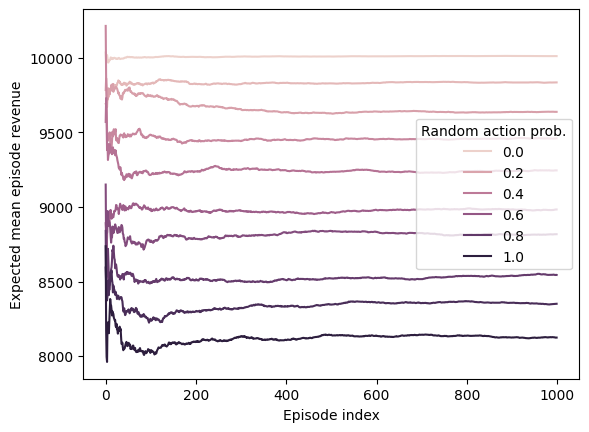

In [ ]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "random_action_prob"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="random_action_prob")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Random action prob.", loc="center right")
plt.savefig(FIGURES_PATH + "experiment_1_revenue_over_time.pdf", format="pdf", bbox_inches="tight")

In [ ]:
# edge of pure PPO over baseline completely random algorithm wrt mean episode revenue over all episodes
mean_episode_revenues = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx==(K-1),:]
mean_episode_revenue_ppo = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==0.0, "mean_episode_revenue"].to_numpy()[0]
mean_episode_revenue_random = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==1.0, "mean_episode_revenue"].to_numpy()[0]

print(f"Pure PPO achieved a mean per-episode reward of {mean_episode_revenue_ppo:.4f}, while the truly random policy: {mean_episode_revenue_random:.4f}.")
print(f"This represents an {(mean_episode_revenue_ppo/mean_episode_revenue_random-1)*100:.2f}% edge for the pure PPO policy over truly random.")

Pure PPO achieved a mean per-episode reward of 10012.3716, while the truly random policy: 8123.7659.
This represents an 23.25% edge for the pure PPO policy over truly random.


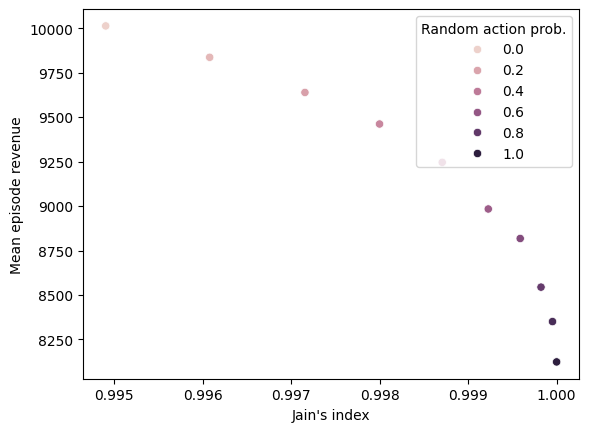

In [ ]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="random_action_prob")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Random action prob.", loc="upper right")
plt.savefig(FIGURES_PATH + "experiment_1_revenue_vs_jains.pdf", format="pdf", bbox_inches="tight")

## Diagnostic plots 
### 1. Looking into which actions were explored and what were their mean reward

In [ ]:
prob = 0.0

actions = action_histories[prob]
rewards = all_rewards[prob]

T, K, L = actions.shape
prices = np.zeros((T, K, L))
for product_idx in range(L):
    prices[:,:,product_idx] = np.round(P_MIN[product_idx] + action_hist[:,:,product_idx] * P_DIFF[product_idx], 10)

# actions: (T, K, 2)   rewards: (T, K)
df = pd.DataFrame({
    "p0": prices[..., 0].ravel(),   # C-order: (t,k) pairs align across all three
    "p1": prices[..., 1].ravel(),
    "reward": rewards.ravel(),
})

mean_r  = df.pivot_table(index="p1", columns="p0", values="reward", aggfunc="mean")
counts  = df.pivot_table(index="p1", columns="p0", values="reward", aggfunc="size")

# heatmap draws row 0 at the top; flip so price increases upward
mean_r = mean_r.sort_index(ascending=False)

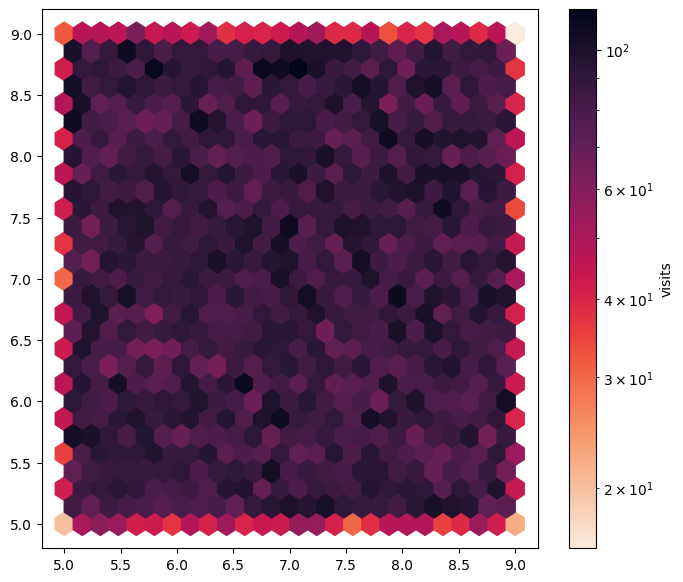

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(df.p0, df.p1,
               gridsize=25, mincnt=1, bins="log", cmap="rocket_r")
fig.colorbar(hb, ax=ax, label="visits")
plt.show()

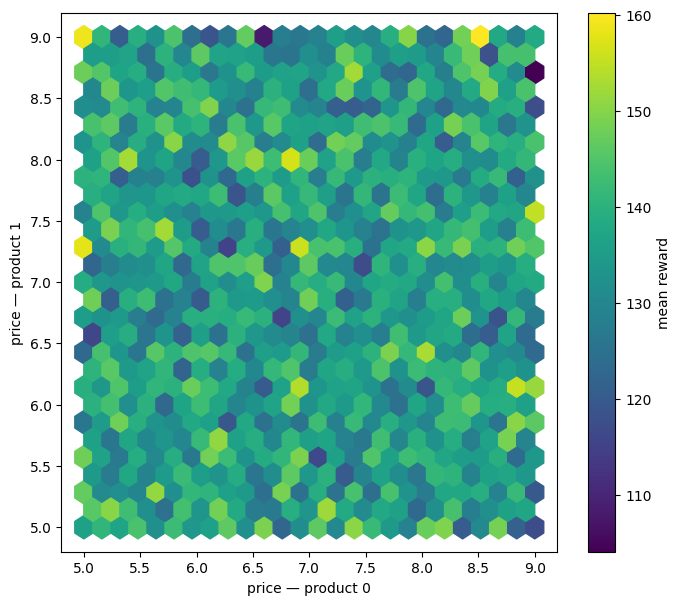

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(df.p0, df.p1, C=df.reward,
               reduce_C_function=np.mean,
               gridsize=25, mincnt=5, cmap="viridis")
fig.colorbar(hb, ax=ax, label="mean reward")
ax.set_xlabel("price — product 0")
ax.set_ylabel("price — product 1")
plt.show()